In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

In [16]:
# Datasets & Dataloaders
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = CIFAR10(root="./data", train=False, download=True, transform=transform)

In [17]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

## Build the CNN

In [18]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # kernel size = 2, stride = 2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # kernel size = 2, stride = 2

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # kernel size = 2, stride = 2
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flattening
        x = self.fc_layers(x)

        return x

In [19]:
model = CNN()

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

## Training the CNN

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        output = model.forward(images) # FP
        loss = criterion(output, labels) # loss fnx
        loss.backward() # BP
        optimizer.step() # update params

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(trainloader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
      for images, labels in testloader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_val_loss += loss.item()

      epoch_val_loss = running_val_loss / len(testloader)
      val_losses.append(epoch_val_loss)

    print(f"epoch={epoch+1}/{epochs} ==> train loss={epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
      best_val_loss = epoch_val_loss
      torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
epoch=1/10 ==> train loss=1.3716987256351334 & val loss = 1.0465441942214966
epoch=2/10 ==> train loss=0.9420055827063978 & val loss = 0.8951478004455566
epoch=3/10 ==> train loss=0.7574129380914562 & val loss = 0.810992419719696
epoch=4/10 ==> train loss=0.6222705721778943 & val loss = 0.7474987506866455
epoch=5/10 ==> train loss=0.5145975831524491 & val loss = 0.7574961185455322
epoch=6/10 ==> train loss=0.42027537326526154 & val loss = 0.7661925554275513
epoch=7/10 ==> train loss=0.3350202372521543 & val loss = 0.831036388874054
epoch=8/10 ==> train loss=0.25489974953710576 & val loss = 0.8492346405982971
epoch=9/10 ==> train loss=0.20002646624441722 & val loss = 0.9664112329483032
epoch=10/10 ==> train loss=0.155997539160635 & val loss = 1.0715237855911255


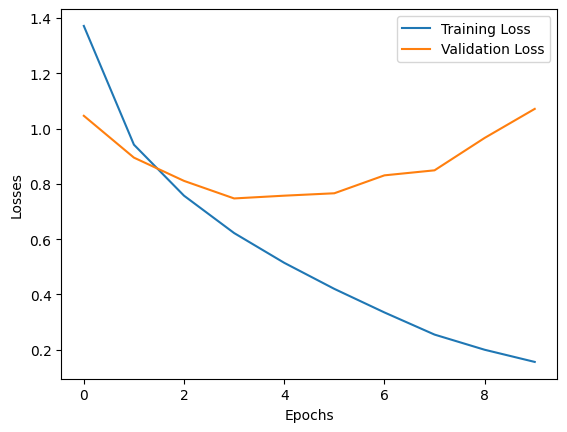

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [ ]:
# Loading the best model
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pt"))

<All keys matched successfully>

In [24]:
# Evaluate our CNN

correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images,labels in testloader:
        outputs = model.forward(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels / total_labels * 100}")

accuracy = 74.15
